<h1 style="text-align: center;">Travel Insurance For XYZ Insurance Company</h1>
<h3 style="text-align: center;">Zian Carlos Wong & Athiyyah</h3>

---

## **Business Understanding**

**(I). Context**

Travel insurance companies currently face significant challenges in managing risk and allocating resources efficiently, due to high uncertainty regarding which policyholders are likely to file a claim. Without accurate predictions, financial planning becomes suboptimal.

**(II). Problem Statement**

The increasing number of policyholders and claim submissions requires insurance companies to identify potential claimants at an earlier stage. Without a predictive model, the company can only become aware of a claim after it has already been filed, leaving little room for proactive risk mitigation or financial planning. Therefore, a machine learning model is needed to predict the likelihood of a customer filing a claim based on historical data, supporting better decision-making and financial planning for the business.

**(III). Goals**

Develop a machine learning classification model capable of predicting customers who are likely to file a claim based on historical travel insurance data. This model is expected to help the company perform early identification of potential claimants, enabling faster, more consistent, and more efficient financial planning.

**(IV). Analytical Approach**

Since the target variable consists of two classes 0 (claim not filed/rejected) and 1 (claim filed/accepted) this problem falls under **binary classification**. A machine learning classification model will be developed to predict the outcome of a claim submission based on historical data.

**(IV). Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

**Machine Learning Metrics:**
Since the target variable is imbalanced, **Average Precision (PR AUC)** is used as the primary metric for model development and comparison. This metric is well-suited for imbalanced classification problems, as it focuses on the model's performance on the positive (minority) class rather than being inflated by the dominant negative class.

For **threshold determination**, **Recall** is prioritized as the key metric. This is because the cost of a False Negative is significantly higher than a False Positive in this business context if the model predicts "no claim" but the customer actually files a claim, the risk was never mitigated, resulting in a large, unanticipated financial loss. Prioritizing recall ensures the model minimizes missed claim cases, even at the cost of more false positives (which only incur manual review costs).

**Business Metrics:**
The ability to correctly identify which transactions/customers are likely to file an insurance claim in the future, enabling the business to proactively flag high-risk cases for manual review before financial loss occurs.

**(V). Success Criteria**

**Machine Learning Performance:**
The model achieves a higher **Average Precision (PR AUC)** score compared to the baseline model, indicating improved capability in identifying the minority (claim) class amid imbalanced data.

**Business Metrics:**
The model, combined with the optimized cost-based threshold, results in a **lower total estimated business cost** (FP + FN cost) compared to using a default threshold (0.5) or no model at all reflecting a reduction in missed claim cases (false negatives) without significantly increasing unnecessary manual reviews (false positives).

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
RANDOM_STATE=42

figure_path="../reports/figure"

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import shap

import shap
from joblib import dump


from feature_engine.outliers import Winsorizer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
    PowerTransformer,
    TargetEncoder,
    LabelEncoder
)

from sklearn.feature_selection import (
    SelectFdr,
    f_classif
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    GradientBoostingClassifier,
)

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import  RandomOverSampler

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    learning_curve
)

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)




1.15.3
1.7.2
0.49.1


In [4]:
df = pd.read_csv("../data/raw/data_travel_insurance_raw.csv")
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.7,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.0,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.0,28,No


In [5]:
x = df.drop("Claim", axis=1)
y = df["Claim"]

In [6]:
num_features = [feature for feature in x.columns if x[feature].dtype != 'O']
cat_features = [feature for feature in x.columns if x[feature].dtype == 'O']

## 1. Data Cleaning (Before Entering Pipeline Model)

**1.1 Rename Column (Optional)**

In [7]:
df = df.rename(columns={
    "Commision (in value)": "Commission"
})

In [8]:
df.columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Gender', 'Duration', 'Destination', 'Net Sales', 'Commission', 'Age',
       'Claim'],
      dtype='object')

**1.2 Fix Categorical Typo (Optional)**

In [9]:
for i in cat_features:
    print(f"Unique Value Of Columns {i}")
    print(x[i].unique())
    print("="*20 )
    print()

Unique Value Of Columns Agency
['C2B' 'EPX' 'JZI' 'CWT' 'LWC' 'ART' 'CSR' 'SSI' 'RAB' 'KML' 'TST' 'TTW'
 'JWT' 'ADM' 'CCR' 'CBH']

Unique Value Of Columns Agency Type
['Airlines' 'Travel Agency']

Unique Value Of Columns Distribution Channel
['Online' 'Offline']

Unique Value Of Columns Product Name
['Annual Silver Plan' 'Cancellation Plan' 'Basic Plan'
 '2 way Comprehensive Plan' 'Bronze Plan' '1 way Comprehensive Plan'
 'Rental Vehicle Excess Insurance' 'Single Trip Travel Protect Gold'
 'Silver Plan' 'Value Plan' '24 Protect' 'Annual Travel Protect Gold'
 'Comprehensive Plan' 'Ticket Protector' 'Travel Cruise Protect'
 'Single Trip Travel Protect Silver' 'Individual Comprehensive Plan'
 'Gold Plan' 'Annual Gold Plan' 'Child Comprehensive Plan' 'Premier Plan'
 'Annual Travel Protect Silver' 'Single Trip Travel Protect Platinum'
 'Annual Travel Protect Platinum' 'Spouse or Parents Comprehensive Plan'
 'Travel Cruise Protect Family']

Unique Value Of Columns Gender
['F' nan 'M']

Uniqu

**1.3 Data Type Change Needed (Optional)**

**1.4 Remove Unrelevant Columns (Optional)**

In [10]:
df.drop("Gender", axis=1, inplace=True)

**1.5 Drop/Fix Ridiculous Value  (Optional)**

**1.5.1 Drop Duplicates**

In [11]:
df.drop_duplicates(inplace=True)

**1.5.2 Drop Row With Age 0**

In [12]:
df = df[df["Age"] != 0]

**1.5.3 Drop Duration Below 1 (Does Not Make Sense)**

In [13]:
df[df["Net Sales"] < 0]

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim
94,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,-216.75,54.19,36,No
116,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,430,AUSTRALIA,-59.40,35.64,41,No
121,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,77,JAPAN,-29.70,17.82,59,No
199,EPX,Travel Agency,Online,Cancellation Plan,29,HONG KONG,-12.00,0.00,36,No
241,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,57,AUSTRALIA,-59.40,35.64,28,No
...,...,...,...,...,...,...,...,...,...,...
43694,EPX,Travel Agency,Online,2 way Comprehensive Plan,140,UNITED STATES,-98.00,0.00,29,No
43743,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,23,MALAYSIA,-29.70,17.82,29,No
43751,EPX,Travel Agency,Online,2 way Comprehensive Plan,147,SPAIN,-68.00,0.00,36,No
43858,EPX,Travel Agency,Online,Cancellation Plan,49,UNITED KINGDOM,-68.00,0.00,36,No


In [14]:
df = df[df["Duration"] > 0]

**1.6 Standardize Categorical Value (Optional)**

**1.7 Domain Knowledge Feature (Optional)**

**1.7.1 Refund Is Made When Net Sales Less Then 0**

In [15]:
df["Is Refund"] = np.where(
    df["Net Sales"] < 0,
    "Yes",
    "No"
)

**1.7.2 Suspected Fraud Insurance Where Net Sales Is Negatif But Commision Is Still Received**

In [16]:
df["Suspected Fraud"] = np.where(
    (df["Is Refund"] == "Yes") & (df["Commission"] > 0),
    "Yes",
    "No"
)

**1.7.3 Calculate Commision Rate Where Net Sales Is Larger Then 0, But If Lesser Then 0 Represent As 0**

In [17]:
df["Commission Rate"] = np.where(
    df["Net Sales"] > 0,
    df["Commission"] / df["Net Sales"],
    0 
)

**1.8 Standardize Target/Dependent Feature (Optional)**

In [18]:
df_interim = df.copy()

le = LabelEncoder()
df_interim["Claim"] =  le.fit_transform(df_interim["Claim"])

**1.8 Export To CSV**

In [19]:
df_interim.to_csv("../data/interim/data_travel_insurance_interim.csv", index=False)

In [20]:
x = df_interim.drop("Claim", axis=1)
y = df["Claim"]

In [21]:
num_features = [feature for feature in x.columns if x[feature].dtype != 'O']
cat_features = [feature for feature in x.columns if x[feature].dtype == 'O']

## 2. Data Understanding

**2.1 General Information**

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 39286 entries, 0 to 44327
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                39286 non-null  object 
 1   Agency Type           39286 non-null  object 
 2   Distribution Channel  39286 non-null  object 
 3   Product Name          39286 non-null  object 
 4   Duration              39286 non-null  int64  
 5   Destination           39286 non-null  object 
 6   Net Sales             39286 non-null  float64
 7   Commission            39286 non-null  float64
 8   Age                   39286 non-null  int64  
 9   Claim                 39286 non-null  object 
 10  Is Refund             39286 non-null  object 
 11  Suspected Fraud       39286 non-null  object 
 12  Commission Rate       39286 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 4.2+ MB


In [23]:
df.shape

(39286, 13)

In [24]:
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim,Is Refund,Suspected Fraud,Commission Rate
0,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,216.0,54.0,57,No,No,No,0.25
1,EPX,Travel Agency,Online,Cancellation Plan,4,MALAYSIA,10.0,0.0,33,No,No,No,0.00
2,JZI,Airlines,Online,Basic Plan,19,INDIA,22.0,7.7,26,No,No,No,0.35
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,20,UNITED STATES,112.0,0.0,59,No,No,No,0.00
4,C2B,Airlines,Online,Bronze Plan,8,SINGAPORE,16.0,4.0,28,No,No,No,0.25


In [25]:
df.isnull().sum()

Agency                  0
Agency Type             0
Distribution Channel    0
Product Name            0
Duration                0
Destination             0
Net Sales               0
Commission              0
Age                     0
Claim                   0
Is Refund               0
Suspected Fraud         0
Commission Rate         0
dtype: int64

**2.2 Feature Information**


| Column                   | Dtype     | Penjelasan                                                                                                                                                            |
| ------------------------ | --------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Agency**               | `object`  | Nama perusahaan atau agen asuransi yang menjual polis perjalanan. Contoh: `"C2B"`, `"EPX"`, `"JZI"`.                                                                  |
| **Agency Type**          | `object`  | Tipe agen asuransi, misalnya apakah merupakan **airline** atau **travel agency**.                                                                                     |
| **Distribution Channel** | `object`  | Cara produk dijual kepada pelanggan, misalnya melalui **Online** atau **Offline**.                                                                                    |
| **Product Name**         | `object`  | Nama atau jenis produk asuransi perjalanan yang dibeli pelanggan.                                                                                                     |
| **Gender**               | `object`  | Jenis kelamin pelanggan, misalnya **Male** atau **Female**. Terdapat banyak missing value pada kolom ini.                                                             |
| **Duration**             | `int64`   | Lama perlindungan asuransi atau durasi perjalanan dalam satuan **hari**. Nilai yang lebih besar menunjukkan masa perlindungan yang lebih lama.                        |
| **Destination**          | `object`  | Negara atau wilayah tujuan perjalanan yang diasuransikan, misalnya **Singapore**, **Japan**, atau **Australia**.                                                      |
| **Net Sales**            | `float64` | Nilai penjualan bersih polis asuransi. Nilai positif menunjukkan penjualan, sedangkan nilai negatif dapat mengindikasikan pembatalan atau pengembalian dana (refund). |
| **Commision (in value)** | `float64` | Besarnya komisi yang diperoleh agen dari penjualan polis asuransi. Umumnya berbanding lurus dengan nilai penjualan.                                                   |
| **Age**                  | `int64`   | Umur pelanggan dalam satuan **tahun** pada saat membeli polis asuransi.                                                                                               |
| **Is Refund**                | `object`  | Polis data yang net salesnya bernilai negatif                    |
| **Commission Rate**                | `float64`  |  Rate Komisi dari Commision Dibagi Net Sales, namun jika net sales sama dengan 0 atau negatif maka value ini bernilai 0             |
| **Suspected Fraud**                | `object`  | Polis data yang bisa menunjukan ini adalah fraud, dengan indikasi net sales bernilai negatif(refund) dan commision bernilai lebih dari 0                      |
| **Claim**                | `object`  | Variabel target yang menunjukkan apakah pelanggan mengajukan klaim asuransi atau tidak. Contohnya **Yes/No** atau **1/0**, tergantung dataset.                        |



**2.3 Statistics Summary**


In [26]:
df.describe()

,Duration,Net Sales,Commission,Age,Commission Rate
count,39286.000000,39286.000000,39286.00000,39286.000000,39286.000000
mean,52.321819,42.225234,10.38828,39.817798,0.171475
std,113.448306,49.716178,20.35260,13.178069,0.218461
min,1.000000,-357.500000,0.00000,1.000000,0.000000
25%,11.000000,19.000000,0.00000,35.000000,0.000000
50%,25.000000,29.000000,0.00000,36.000000,0.000000
75%,57.000000,50.000000,11.88000,44.000000,0.350000
max,4881.000000,810.000000,283.50000,118.000000,0.650189


## 3. Exploratory Data Analysis (EDA)

**3.1 Univariate Analysis (Target)**
> *Hasil:* Dari hasil univariate analysis ke target, distribusi target terindikasi imbalanced dataset.


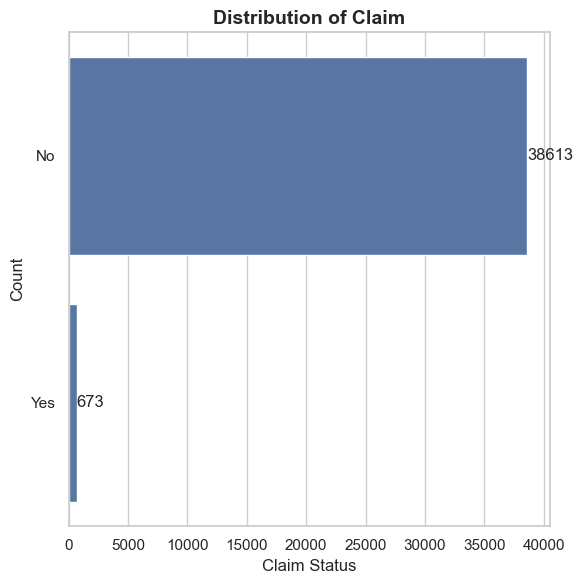

In [27]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 6))

ax = sns.countplot(
   y
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Distribution of Claim", fontsize=14, fontweight="bold")
ax.set_xlabel("Claim Status")
ax.set_ylabel("Count")

plt.tight_layout()

plt.savefig(f"{figure_path}/univariate/target/claim_distribution", dpi=300, bbox_inches="tight")
    
plt.show()

**3.2 Univariate Analysis (Numeric)**


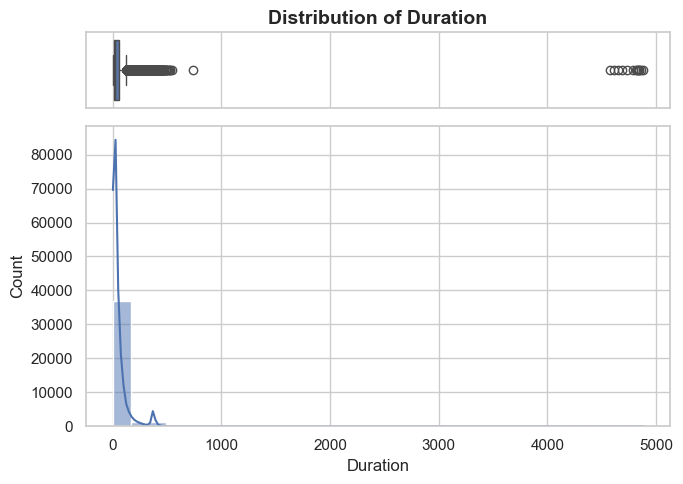

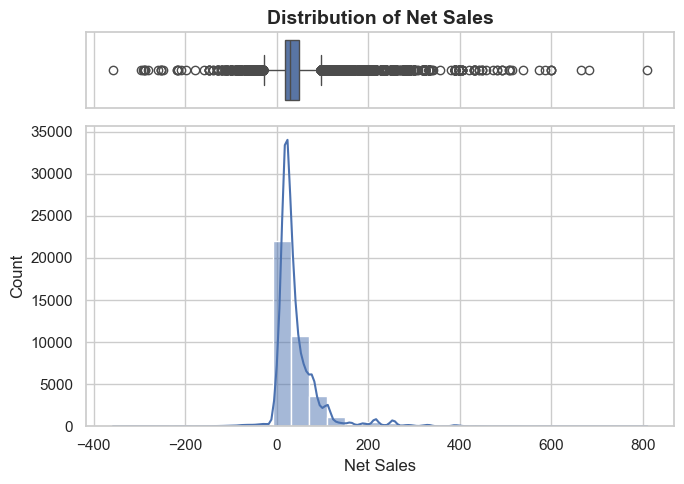

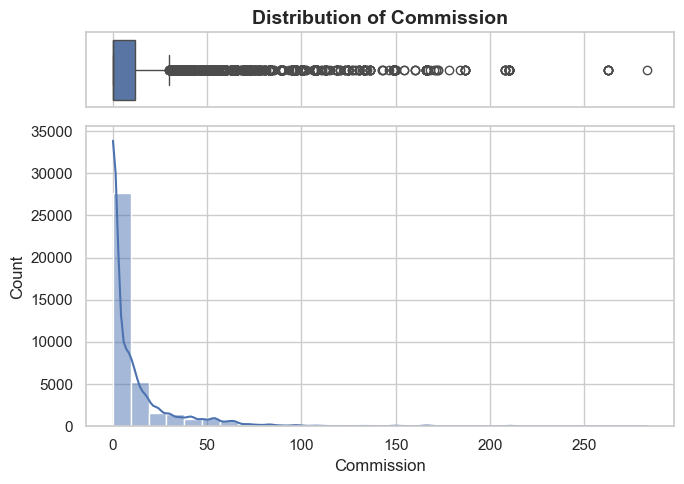

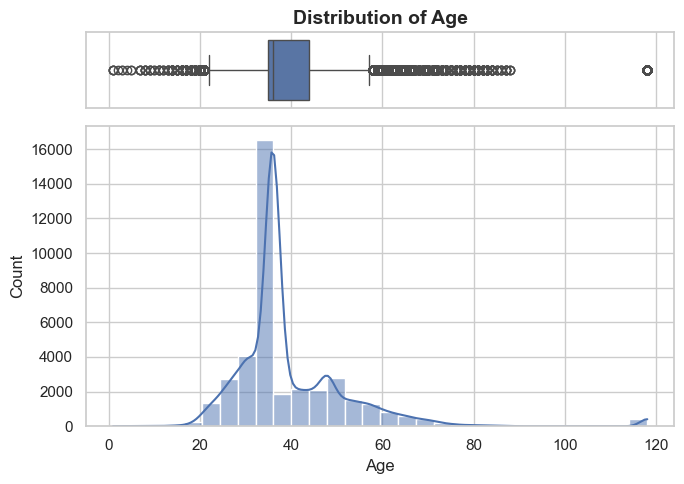

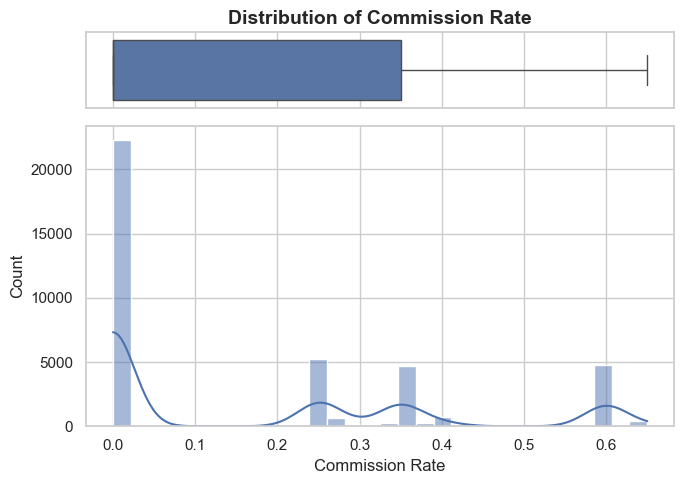

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid")

for feature in num_features:

    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        figsize=(7, 5), 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

    sns.boxplot(
        x=x[feature],
        ax=ax_box
    )
    ax_box.set(xlabel='') 
    
    ax_box.set_title(
        f"Distribution of {feature}", 
        fontsize=14, 
        fontweight="bold"
    )

    sns.histplot(
        x=x[feature],
        bins=30,
        kde=True,
        ax=ax_hist
    )

    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/univariate/numeric/{feature.lower().replace(' ', '_')}_hist_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.3 Univariate Analysis (Kategorik)**


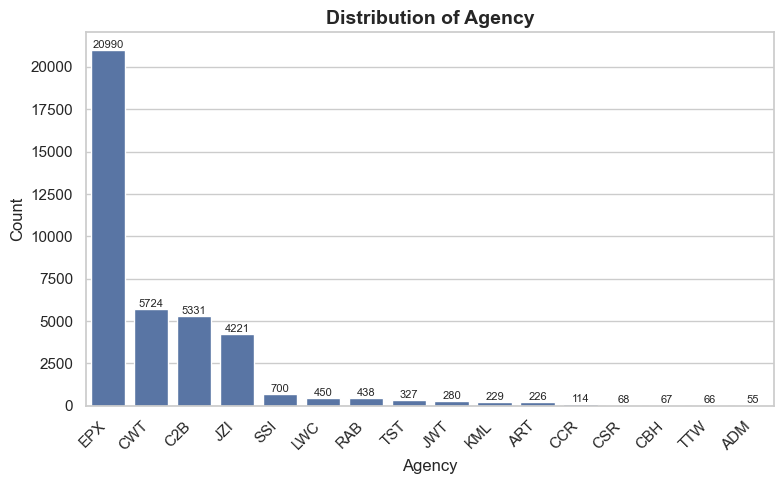

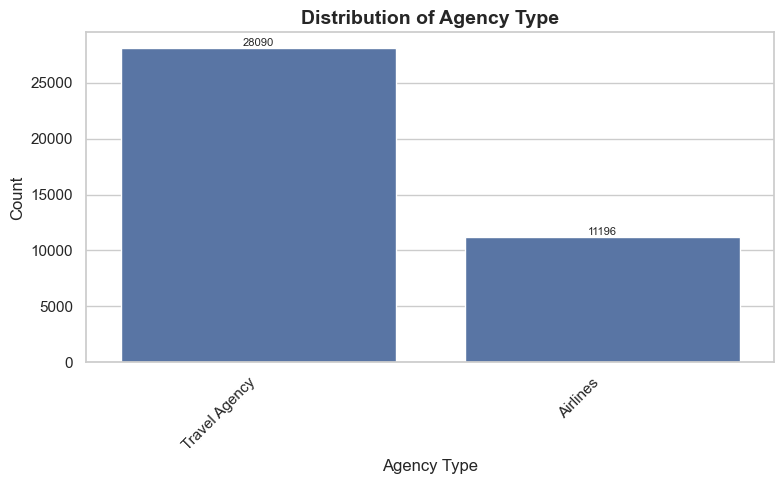

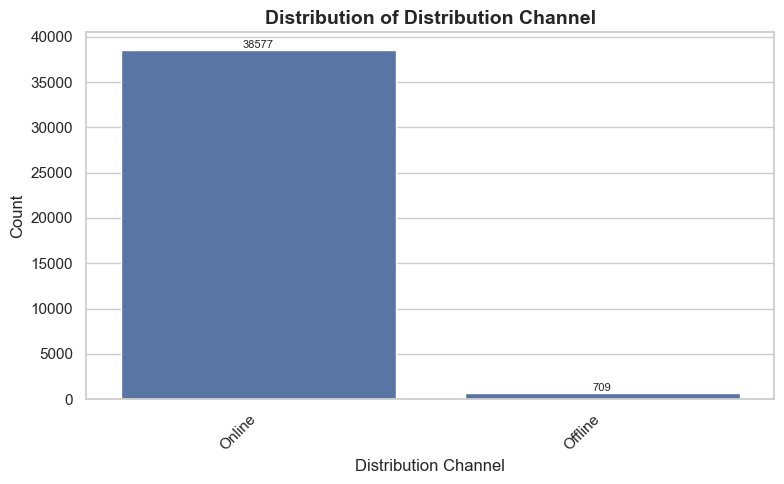

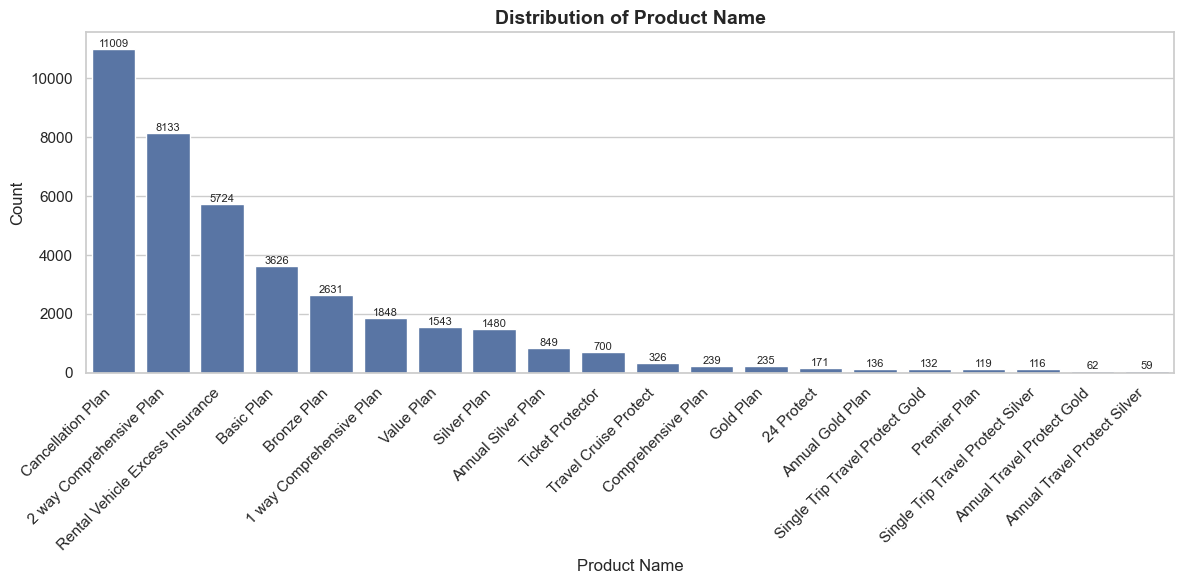

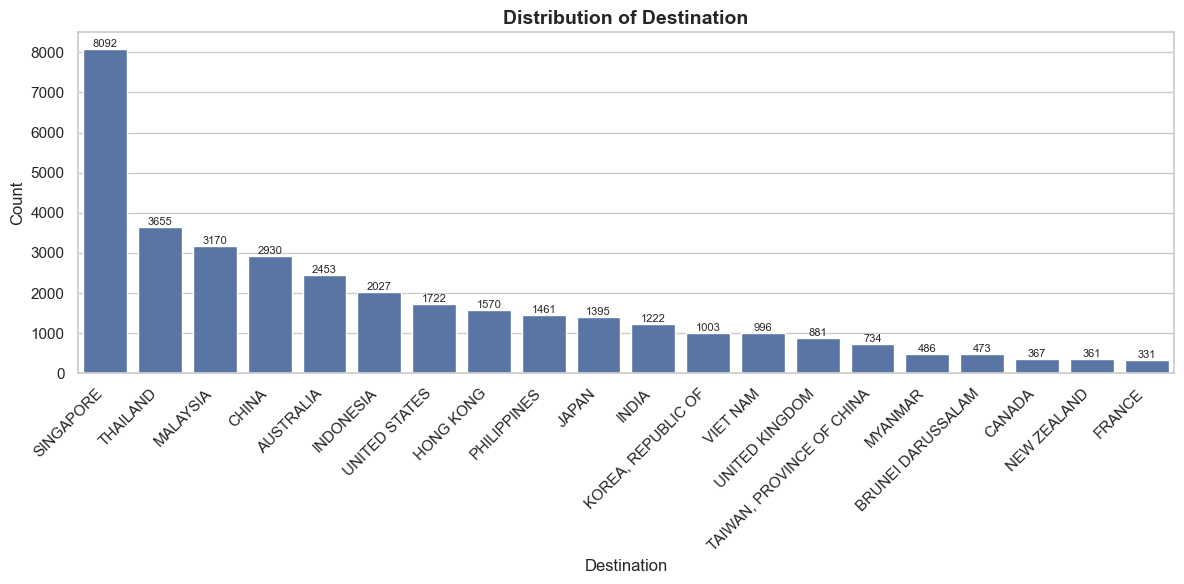

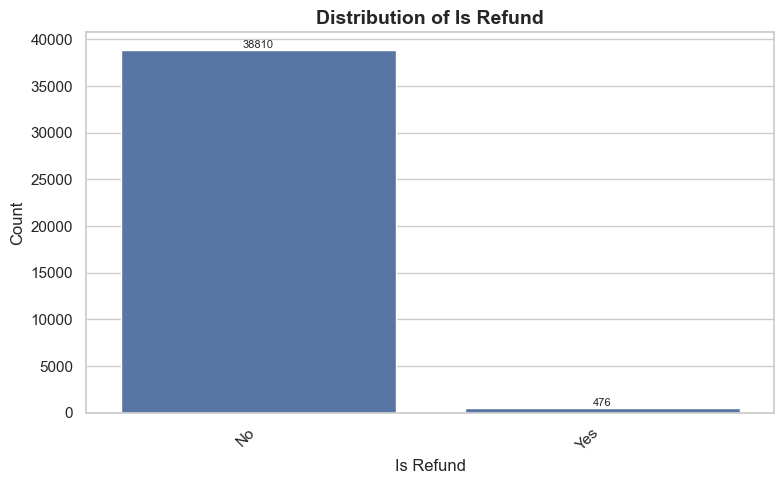

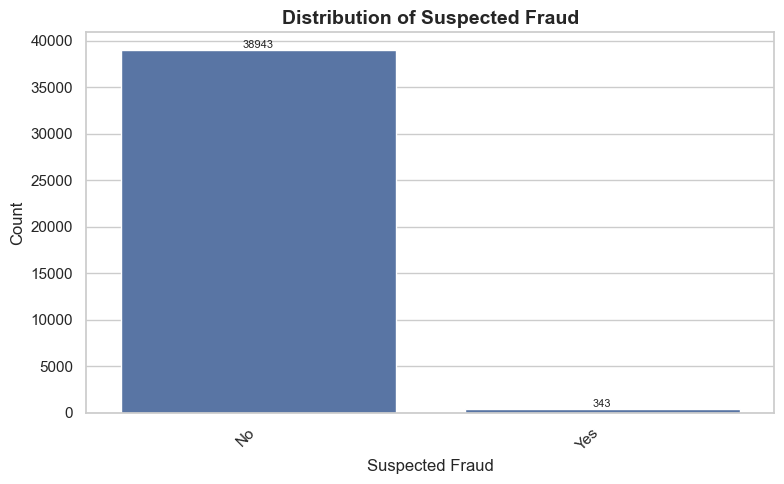

In [29]:
sns.set_theme(style="whitegrid")

for feature in cat_features:
    
    n_categories = x[feature].nunique()

    # Limit categories if too many
    if n_categories > 20:
        order = x[feature].value_counts().nlargest(20).index
        figsize = (12, 6)
    else:
        order = x[feature].value_counts().index
        figsize = (max(8, n_categories * 0.5), 5)

    plt.figure(figsize=figsize)

    ax = sns.countplot(
        x=x[feature],
        order=order
    )

    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    # Rotate x labels
    plt.xticks(rotation=45, ha="right")

    # Title and labels
    plt.title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.tight_layout()


    plt.savefig(
        f"{figure_path}/univariate/categoric/{feature.lower().replace(' ', '_')}_countplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.4 Bivariate Analaysis (Kategorik To Target)**


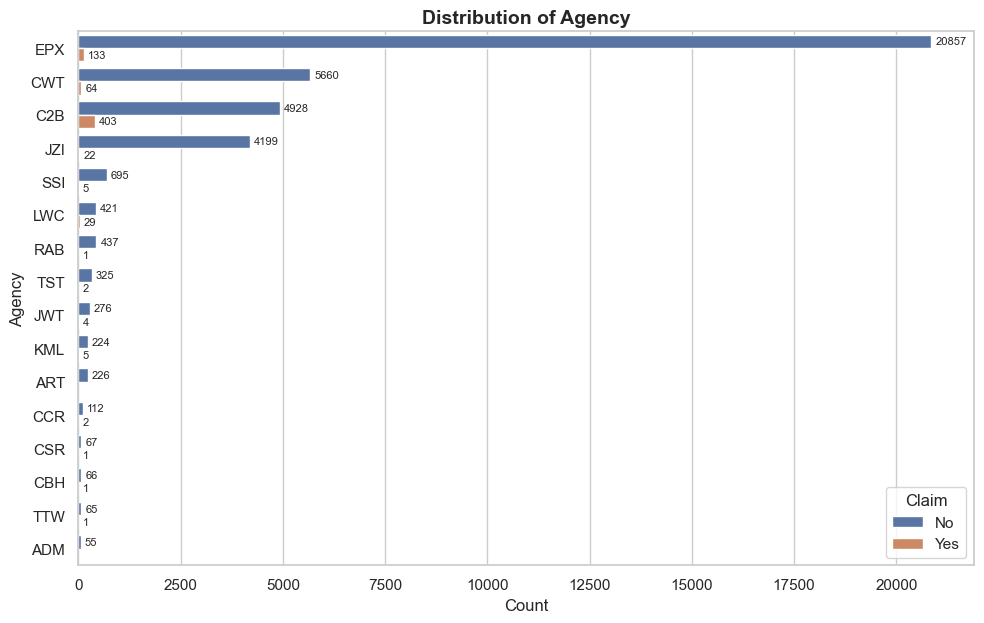

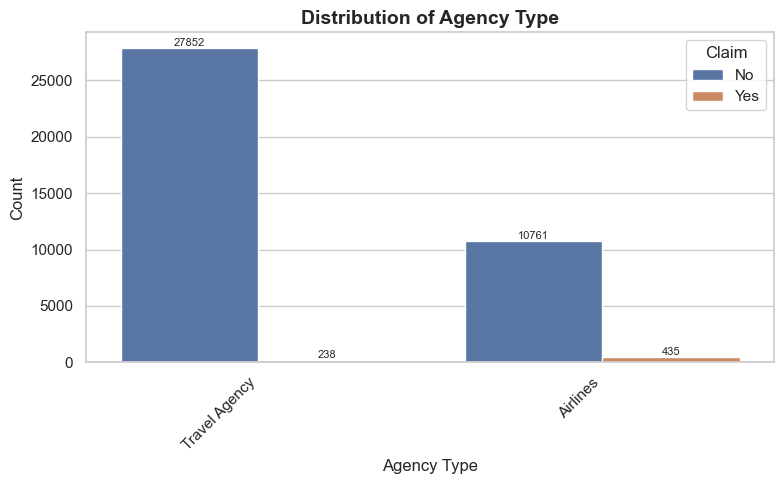

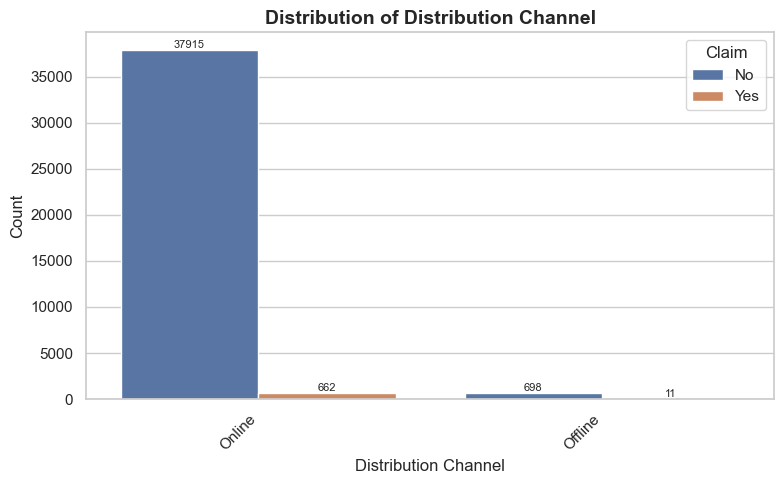

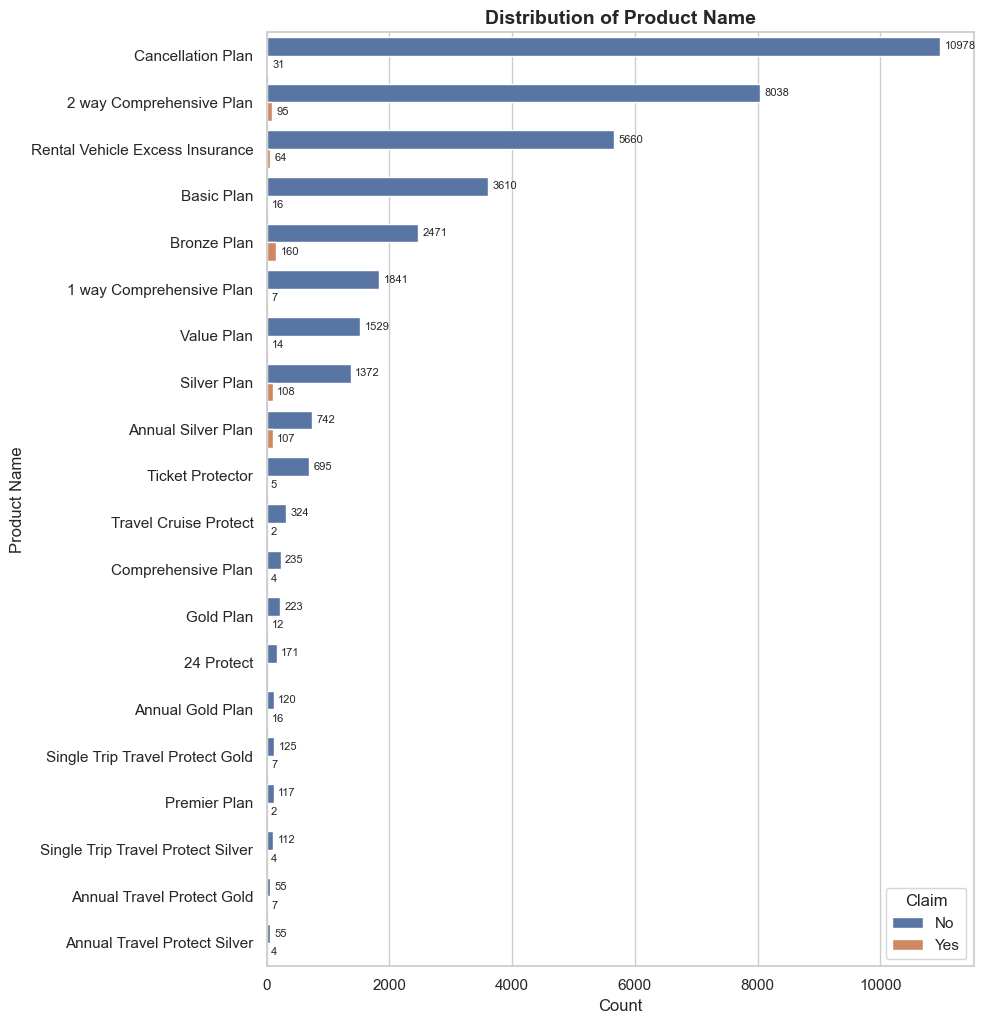

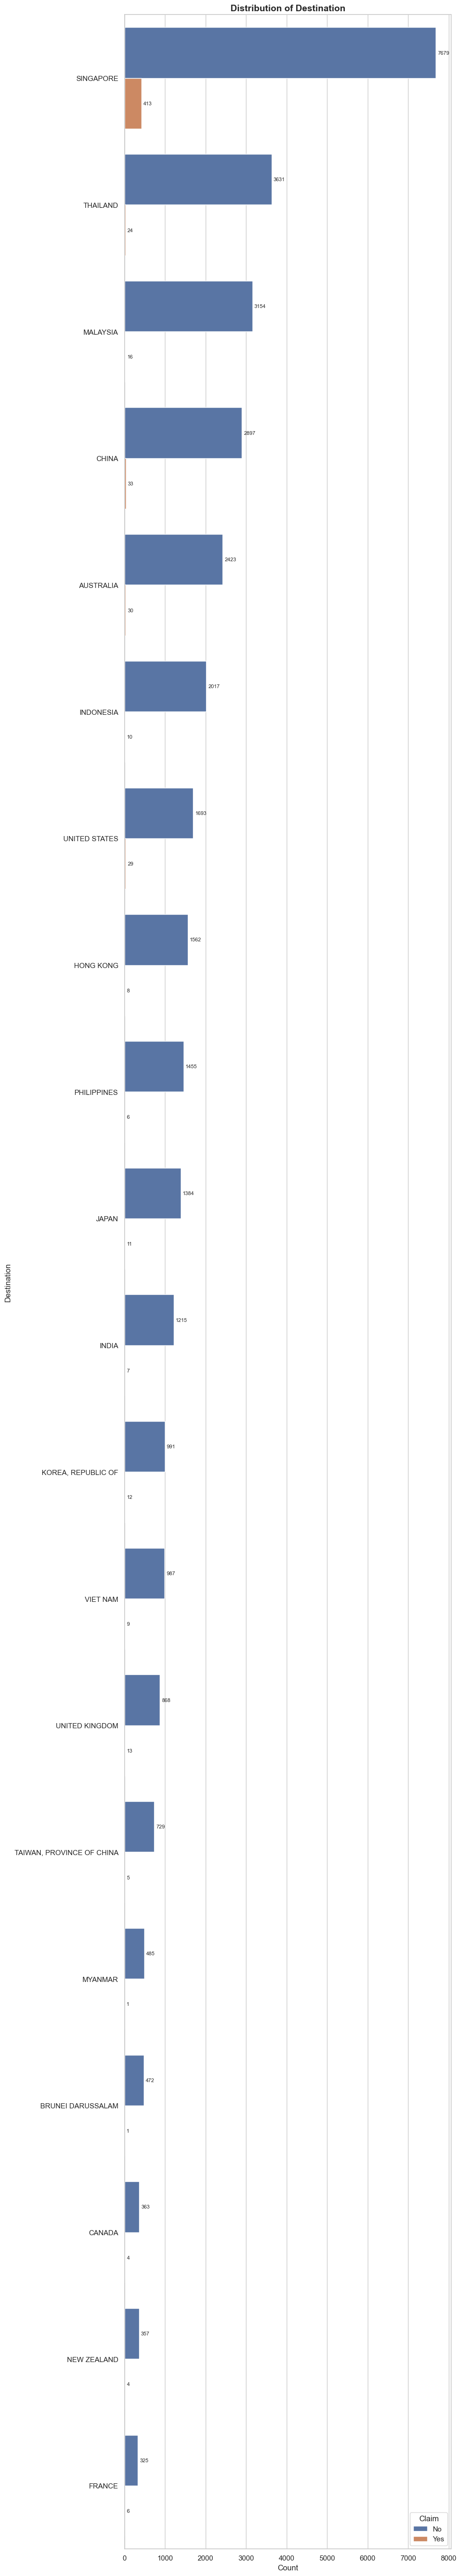

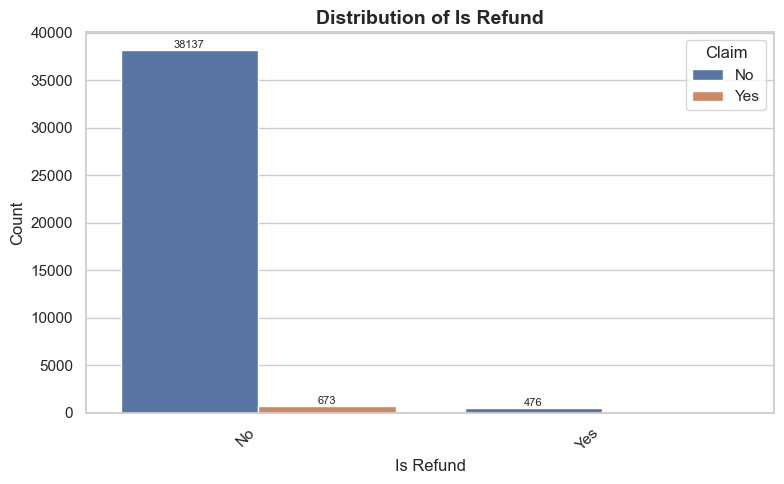

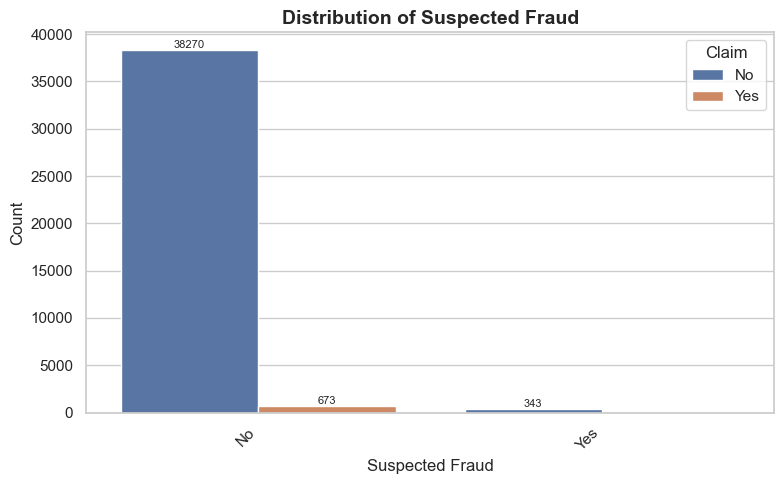

In [30]:
sns.set_theme(style="whitegrid")

for feature in cat_features:
    
    n_categories = x[feature].nunique()

    if n_categories > 20:
        order = x[feature].value_counts().nlargest(20).index
    else:
        order = x[feature].value_counts().index

    if n_categories > 10:
        figsize = (10, max(6, n_categories * 0.4)) 
        plt.figure(figsize=figsize)
        
        ax = sns.countplot(
            y=x[feature],
            hue=y,
            order=order
        )
        
        for container in ax.containers:
            ax.bar_label(container, fontsize=8, padding=3)
            
        plt.ylabel(feature)
        plt.xlabel("Count")
        
    else:
        figsize = (max(8, n_categories * 0.5), 5)
        plt.figure(figsize=figsize)
        
        ax = sns.countplot(
            x=x[feature],
            hue=y,
            order=order
        )
            
        for container in ax.containers:
            ax.bar_label(container, fontsize=8)

        plt.xticks(rotation=45, ha="right")
        
        plt.xlabel(feature)
        plt.ylabel("Count")

    plt.title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/bivariate/categoric/{feature.lower().replace(' ', '_')}_countplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.5 Bivariate Analaysis (Numeric To Target)**


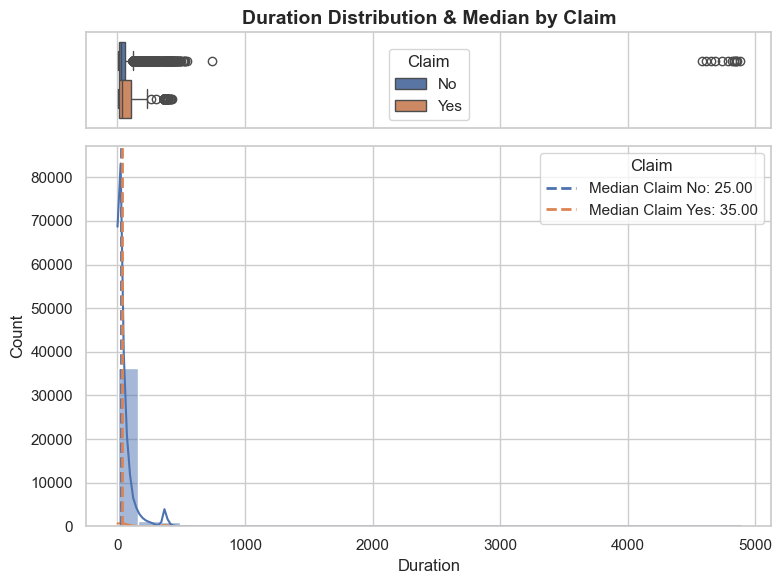

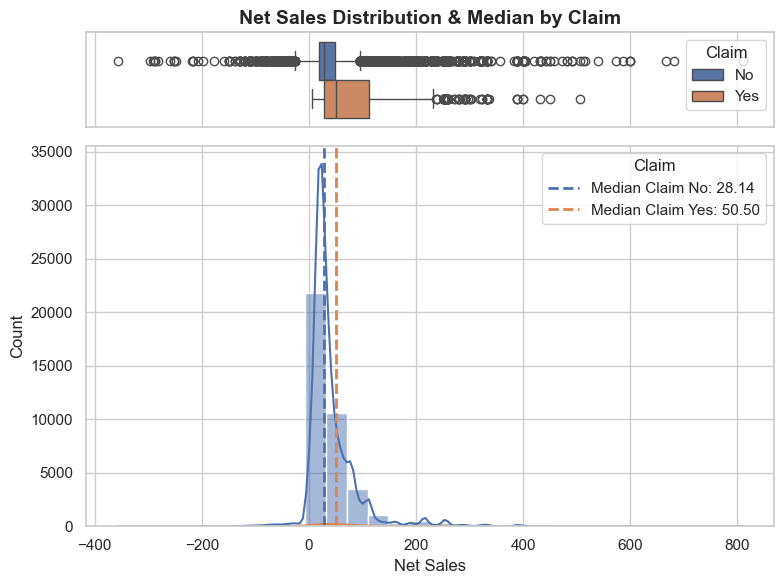

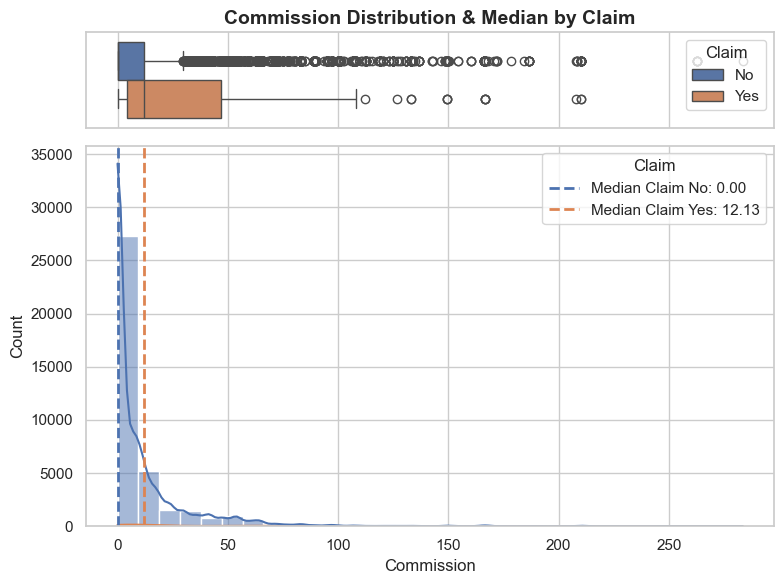

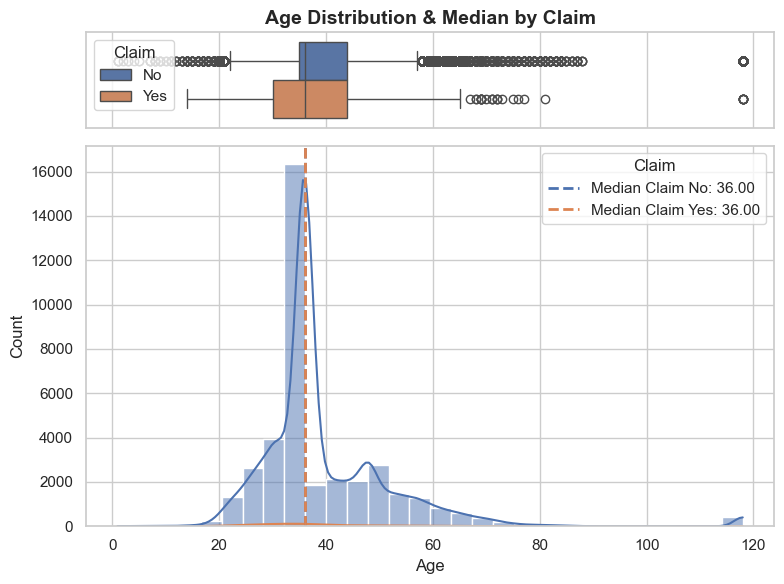

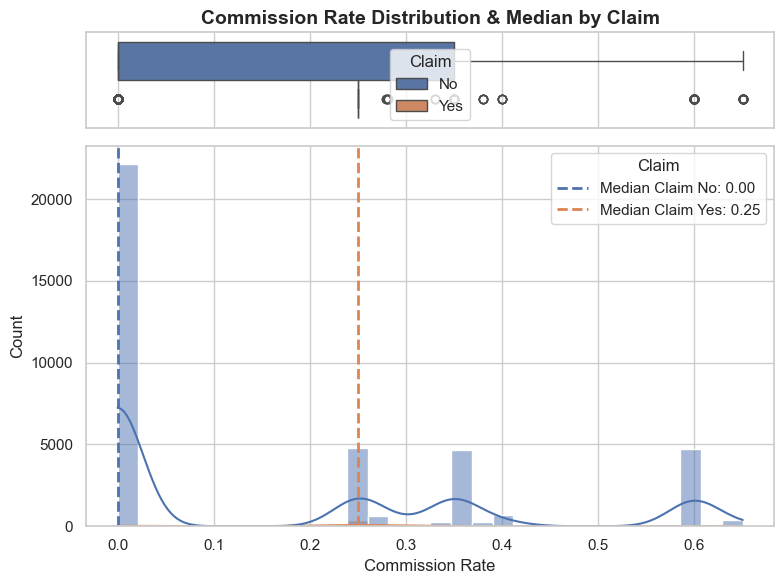

In [31]:
sns.set_theme(style="whitegrid")

for feature in num_features:
    
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, 
        figsize=(8, 6), 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.2, 0.8)}
    )

    sns.boxplot(
        x=x[feature],
        hue=y,
        ax=ax_box
    )
    ax_box.set(xlabel='') 
    
    ax_box.set_title(
        f"{feature} Distribution & Median by Claim",
        fontsize=14,
        fontweight="bold"
    )

    sns.histplot(
        x=x[feature],
        hue=y,
        bins=30,
        kde=True,
        ax=ax_hist
    )

    colors = sns.color_palette(n_colors=y.nunique())
    unique_targets = sorted(y.unique())
    
    for target, color in zip(unique_targets, colors):
        median_val = x[y == target][feature].median()
        ax_hist.axvline(
            median_val, 
            color=color, 
            linestyle="--", 
            linewidth=2, 
            label=f"Median Claim {target}: {median_val:.2f}"
        )

    ax_hist.legend(title=y.name if hasattr(y, 'name') else 'Target')
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        f"{figure_path}/bivariate/numeric/{feature.lower().replace(' ', '_')}_perfect_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

**3.6 Correlation & Multicollinearity**

**3.6.1 Correlation Check (Visual Check & Threholds Check)**
> *Hasil:* dari hasil analisis korelasi yang ditampilkan menggunakan heatmap kita bisa memakai guidelines dibawah ini.

| Nilai Korelasi | Aksi |
|-------------------|--------|
| < 0.5             | Aman |
| 0.5 - 0.8         | Investigasi Fitur |
| > 0.8             | Boleh Dihapus |
| > 0.9             | Layak Dihapus |

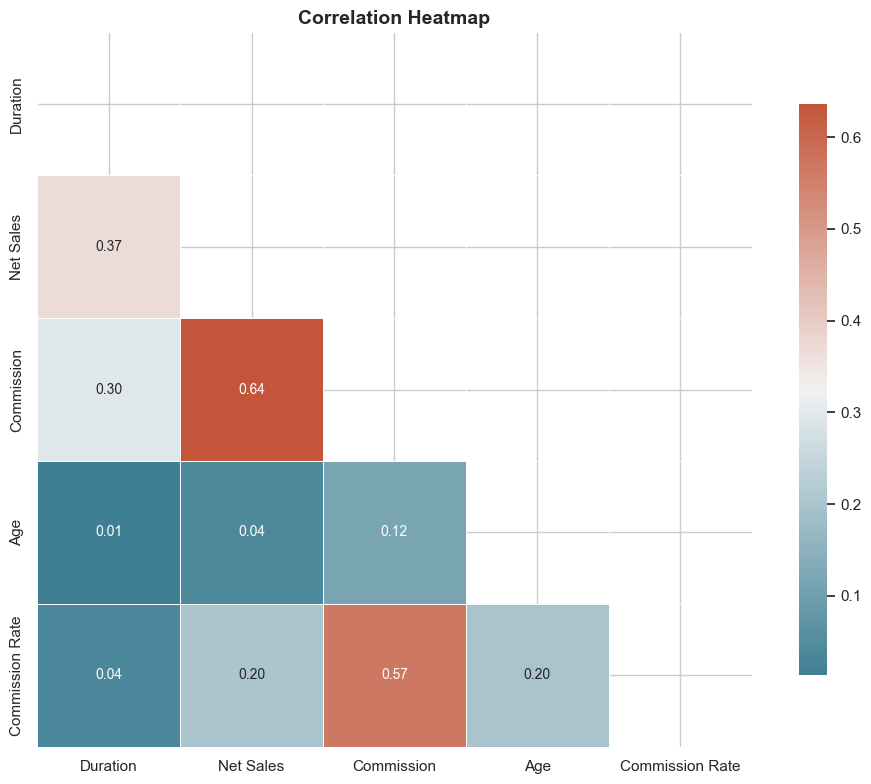

In [32]:
corr_matrix = x.corr(numeric_only=True)

# Buat heatmap dengan styling menarik
plt.figure(figsize=(10, 8))

# Custom diverging colormap
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Buat mask segitiga atas agar lebih clean
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"fontsize": 10}
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
def check_correlated_independent_feature(dataset, threshold):
    col_correlated = set()
    corr_matrix = dataset.corr(numeric_only=True)
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_correlated.add(colname)
                
    return col_correlated

corr_features = check_correlated_independent_feature(x, 0.80)
print("Feature Correlated Check With Thresholds > 0.80:", corr_features)

Feature Correlated Check With Thresholds > 0.80: set()


**3.6.1 Variance Inflation Factor**
> *Hasil:* Seluruh VIF value aman. dikarenakan tidak ada fitur yang memiliki nilai VIF > 10.

| Nilai Korelasi | Aksi |
|-------------------|--------|
| > 10            | Hapus Kolom |
| < 10      | Simpan Kolom (VIF Aman) |

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_score = pd.DataFrame()

vif_score["Feature"] = x[num_features].columns
vif_score["VIF"] = [
    variance_inflation_factor(x[num_features].values, i)
    for i in range(x[num_features].shape[1])
]

vif_score


,Feature,VIF
0,Duration,1.422640
1,Net Sales,3.038929
2,Commission,3.164687
3,Age,2.328839
4,Commission Rate,2.606625


## **Section 4. Data Preparation**

In [35]:
READ_CSV="../data/interim/data_travel_insurance_interim.csv"
RANDOM_STATE=42

TARGET_TRANSFORM_COLS = ["Destination"]
LOG_TRANSFORM_COLS= ["Duration", "Net Sales"]

In [36]:
df = pd.read_csv(READ_CSV)
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Duration,Destination,Net Sales,Commission,Age,Claim,Is Refund,Suspected Fraud,Commission Rate
0,C2B,Airlines,Online,Annual Silver Plan,365,SINGAPORE,216.0,54.0,57,0,No,No,0.25
1,EPX,Travel Agency,Online,Cancellation Plan,4,MALAYSIA,10.0,0.0,33,0,No,No,0.00
2,JZI,Airlines,Online,Basic Plan,19,INDIA,22.0,7.7,26,0,No,No,0.35
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,20,UNITED STATES,112.0,0.0,59,0,No,No,0.00
4,C2B,Airlines,Online,Bronze Plan,8,SINGAPORE,16.0,4.0,28,0,No,No,0.25


**4.1 Initialization**

In [37]:
x = df.drop(columns=["Claim"])
y = df["Claim"]

**4.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset) & Handling Imbalanced Dataset** 

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [39]:
NUMERIC_COLS = [features for features in x_train.columns if x_train[features].dtypes != "O"]
CATEGORICAL_COLS = [features for features in x_train.columns if x_train[features].dtypes == "O"]

**4.3 Data Transformation (Feature Engineering)**

In [40]:
numeric_pipeline = Pipeline([
    ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
    ("RobustScaler", RobustScaler()),
])

numeric_log_pipeline = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("RobustScaler", RobustScaler()),
])

categorical_ohe_pipeline = Pipeline([
    ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
 ])

categorical_target_pipeline = Pipeline([
    ("TargetEncoder", TargetEncoder())
])
    
preprocessor = ColumnTransformer(
    [
        ("numeric_pipeline", numeric_pipeline, [c for c in NUMERIC_COLS if c not in LOG_TRANSFORM_COLS]),
        ("numeric_log_pipeline", numeric_log_pipeline, LOG_TRANSFORM_COLS),
        ("categorical_ohe_pipeline", categorical_ohe_pipeline, [c for c in CATEGORICAL_COLS if c not in TARGET_TRANSFORM_COLS]),
        ("categorical_target_pipeline", categorical_target_pipeline, TARGET_TRANSFORM_COLS),
    ],
    remainder="drop"
)   

**4.4 Overview**

## **Section 5. Model Development**

**5.1 Initialization**

In [41]:
def benchmark_models(pipelines, x_train, y_train, cv=5):
    all_cv_result = []

    for name, pipeline in pipelines.items():
        cv_result = cross_validate(
            estimator=pipeline,
            X=x_train, y=y_train,
            cv=cv,
            scoring="average_precision",
            return_train_score=True,
            n_jobs=-1 
        )
        
        pipeline.fit(x_train, y_train)
        


        all_cv_result.append({
            "name": name,
            "mean_ap_train_score": np.mean(cv_result["train_score"]),
            "mean_ap_validate_score": np.mean(cv_result["test_score"]),
            "mean_sd_train_score": np.std(cv_result["train_score"]),
            "mean_sd_validate_score": np.std(cv_result["test_score"]),
        })
        
        

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_ap_validate_score", ascending=False
    ).reset_index(drop=True)

    return result_df

def base_pipeline():
    numeric_pipeline = Pipeline([
        ("winsorizer_iqr", Winsorizer(capping_method="iqr", fold=1.5)),
        ("RobustScaler", RobustScaler()),
    ])

    categorical_ohe_pipeline = Pipeline([
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
    ])

    preprocessor = ColumnTransformer(
        [
            ("numeric_pipeline", numeric_pipeline, NUMERIC_COLS),
            ("categorical_ohe_pipeline", categorical_ohe_pipeline, CATEGORICAL_COLS),
        ],
        remainder="drop"
    )
    
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(random_state=42))
        ]
    )

**5.2 Developing the Model Pipeline**

In [42]:
tuned_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFdr(score_func=f_classif, alpha=0.005)),
    ("resampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
])
    
best_params = {
    'classifier__learning_rate': 0.020585312110064476,
    'classifier__max_depth': 4,
    'classifier__max_features': 'log2',
    'classifier__min_samples_leaf': 26,
    'classifier__min_samples_split': 42,
    'classifier__n_estimators': 177,
    'classifier__subsample': 0.8227412591061039
}

tuned_pipeline.set_params(**best_params)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('numeric_log_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**6.3 Model Benchmarking (Comparing model base performance)**

In [43]:
logreg_base_pipeline = base_pipeline()
gb_base_pipeline = base_pipeline()
gb_base_pipeline.set_params(classifier=GradientBoostingClassifier(random_state=RANDOM_STATE))

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_pipeline', ...), ('categorical_ohe_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
pipelines = {
    "Base LogReg": logreg_base_pipeline,
    "Base GB (Default)": gb_base_pipeline,
    "Tuned GB (Optimized)": tuned_pipeline
}

pipelines = {
    "Base LogReg": logreg_base_pipeline,
    "Base GB": gb_base_pipeline,
    "Tuned GB": tuned_pipeline,
}

results = benchmark_models(
    pipelines,
    x_train,
    y_train,
)

results

,name,mean_ap_train_score,mean_ap_validate_score,mean_sd_train_score,mean_sd_validate_score
0,Tuned GB,0.114574,0.095975,0.004149,0.013239
1,Base LogReg,0.087203,0.083697,0.001646,0.006475
2,Base GB,0.217658,0.076417,0.003406,0.006738


In [72]:
base_ap = results.loc[results["name"] == "Base GB", "mean_ap_validate_score"].values[0]
tuned_ap = results.loc[results["name"] == "Tuned GB", "mean_ap_validate_score"].values[0]

pct_increase = ((tuned_ap - base_ap) / base_ap) * 100

print(f"Base GB Validation AP: {base_ap:.6f}")
print(f"Tuned GB Validation AP: {tuned_ap:.6f}")
print(f"Percentage increase: {pct_increase:.2f}%")

Base GB Validation AP: 0.076417
Tuned GB Validation AP: 0.095975
Percentage increase: 25.59%


**6.5 Analyze Model**

**6.5.1 Test Data AP Score**

The test data AP scores receives an increases if our standpoint is from mean ap validation score. 

In [45]:
tuned_pipeline.fit(x_train, y_train)

y_test_pred_proba = tuned_pipeline.predict_proba(x_test)[:, 1]
print("Average Precision On Test Set:", average_precision_score(y_test, y_test_pred_proba))

Average Precision On Test Set: 0.11294464275237324


**6.5.2 Test Data AP Confusion Matrix**

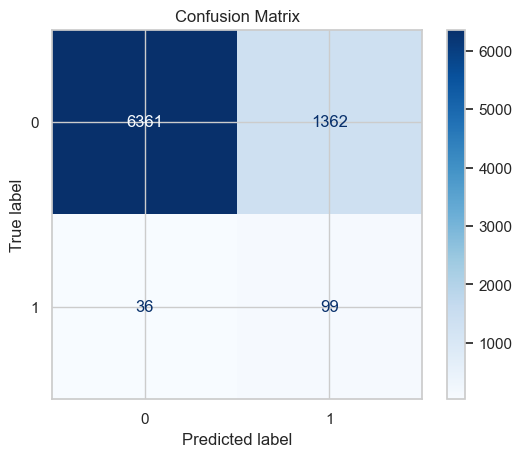

In [46]:
ConfusionMatrixDisplay.from_estimator(
    tuned_pipeline,
    x_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

 **6.5.1 Learning Curve**

The learning curve was used to evaluate the model's learning behavior and generalization performance as the training data increased.

**Observations:**
- The training AP gradually decreases as more training samples are added.
- The validation AP steadily improves with additional training data.
- A small gap remains between the training and validation curves, indicating **mild overfitting**.
- Both curves begin to converge toward the end, suggesting that the tuned Gradient Boosting model generalizes reasonably well.

Overall, the learning curve indicates that hyperparameter tuning successfully reduced overfitting compared to the baseline model, although a slight degree of overfitting still exists.

In [47]:
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=tuned_pipeline,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

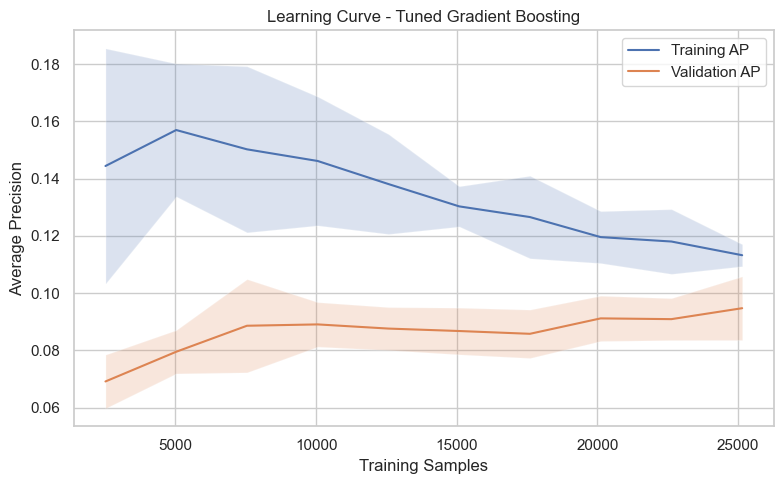

In [48]:
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training AP")
plt.plot(train_sizes, valid_mean, label="Validation AP")

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    valid_mean-valid_std,
    valid_mean+valid_std,
    alpha=0.2
)

plt.xlabel("Training Samples")
plt.ylabel("Average Precision")
plt.title("Learning Curve - Tuned Gradient Boosting")
plt.legend()

plt.tight_layout()
plt.show()

**6.6 Thresholds Optimization**

**6.6.1 Visualize PR AUC**

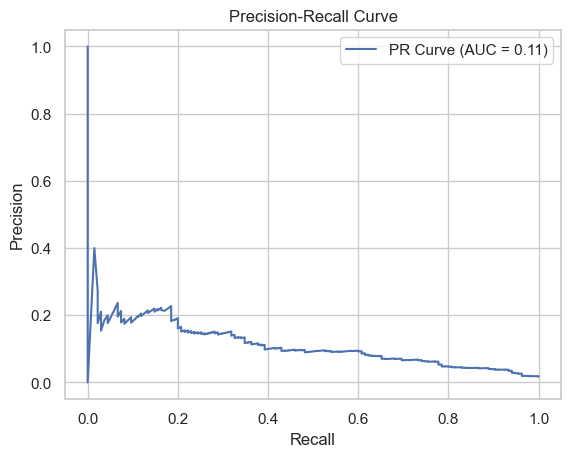

In [49]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba)
auc_pr = average_precision_score(y_test, y_test_pred_proba)

plt.plot(recall, precision, label=f'PR Curve (AUC = {auc_pr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


**6.6.2 Threshold Optimization Using Cost Matrix**

The default classification threshold (0.5) may not minimize business cost. Therefore, multiple thresholds were evaluated using a cost matrix.

| Outcome | Business Cost |
|---------|--------------:|
| False Positive (FP) | Rp300,000 (manual review by analyst and legal team) |
| False Negative (FN) | Rp42,000,000 (average travel insurance claim payout) |

For each threshold, the total business cost was calculated as:

`Total Cost = (FP × Rp300,000) + (FN × Rp42,000,000)`

The threshold with the lowest total cost was selected as the final operating threshold.

In [ ]:
results = []

cost_fn = 42000000    # Model memprediksi tidak claim, tetapi ternyata claim.
cost_fp = 300000     # Model memprediksi claim, tetapi tidak klaim

for threshold in thresholds:
    y_pred = (y_test_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = fn * cost_fn + fp * cost_fp
    

    results.append({
        "Threshold": threshold,
        "Recall": tp / (tp + fn),
        "Precision": tp / (tp + fp) if (tp + fp) else 0,
        "FP": fp,
        "FN": fn,
        "Total Cost": total_cost
    })

df_threshold = pd.DataFrame(results)
df_threshold.sort_values("Total Cost")[:100]

,Threshold,Recall,Precision,FP,FN,Total Cost
3767,0.313506,0.933333,0.038101,3181,9,1332300000
3766,0.313473,0.933333,0.038089,3182,9,1332600000
3765,0.313436,0.933333,0.038078,3183,9,1332900000
3764,0.313380,0.933333,0.038066,3184,9,1333200000
3763,0.313352,0.933333,0.038055,3185,9,1333500000
...,...,...,...,...,...,...
3801,0.316034,0.925926,0.038238,3144,10,1363200000
3800,0.316021,0.925926,0.038226,3145,10,1363500000
3799,0.316012,0.925926,0.038215,3146,10,1363800000
3676,0.306799,0.933333,0.036928,3286,9,1363800000


In [65]:
threshold = 0.5
y_pred_default = (y_test_pred_proba >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()

default_cost = fn * cost_fn + fp * cost_fp

print(f"Threshold: {threshold}")
print(f"FP: {fp}, FN: {fn}")
print(f"Total Cost at default threshold: Rp{default_cost:,.0f}")

Threshold: 0.5
FP: 1362, FN: 36
Total Cost at default threshold: Rp1,920,600,000


**6.6.2 Scoring After Threshold Optimization**

In [ ]:
best_threshold = 0.313506
y_pred = (y_test_pred_proba >= best_threshold).astype(int)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Recall After Thresholds Optimization On Test Set:", recall)
print("Precision After Thresholds Optimization On Test Set:", precision)
print("F1 Score After Thresholds Optimization On Test Set:", f1)

Recall After Thresholds Optimization On Test Set: 0.9333333333333333
Precision After Thresholds Optimization On Test Set: 0.03810099788327789
F1 Score After Thresholds Optimization On Test Set: 0.07321324811156305


**6.6.3 Confusions Matrix After Threshold Optimization**

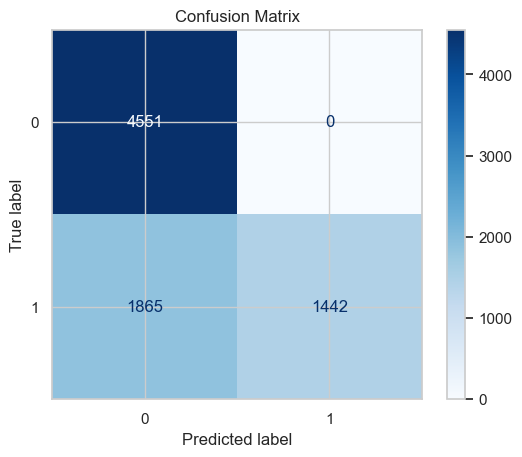

In [61]:
ConfusionMatrixDisplay.from_estimator(
    tuned_pipeline,
    x_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

**6.7 Model Explanation and Interpretation**

**6.7.1 Feature Importances**

In [53]:
features = tuned_pipeline[:2].get_feature_names_out()
features_names = list(map(lambda x: x.split("__")[1],features))
feature_importances = tuned_pipeline.named_steps["classifier"].feature_importances_

df = pd.DataFrame({
    "Feature": features_names,
    "Importance": feature_importances
})

df = df.sort_values("Importance", ascending=True)

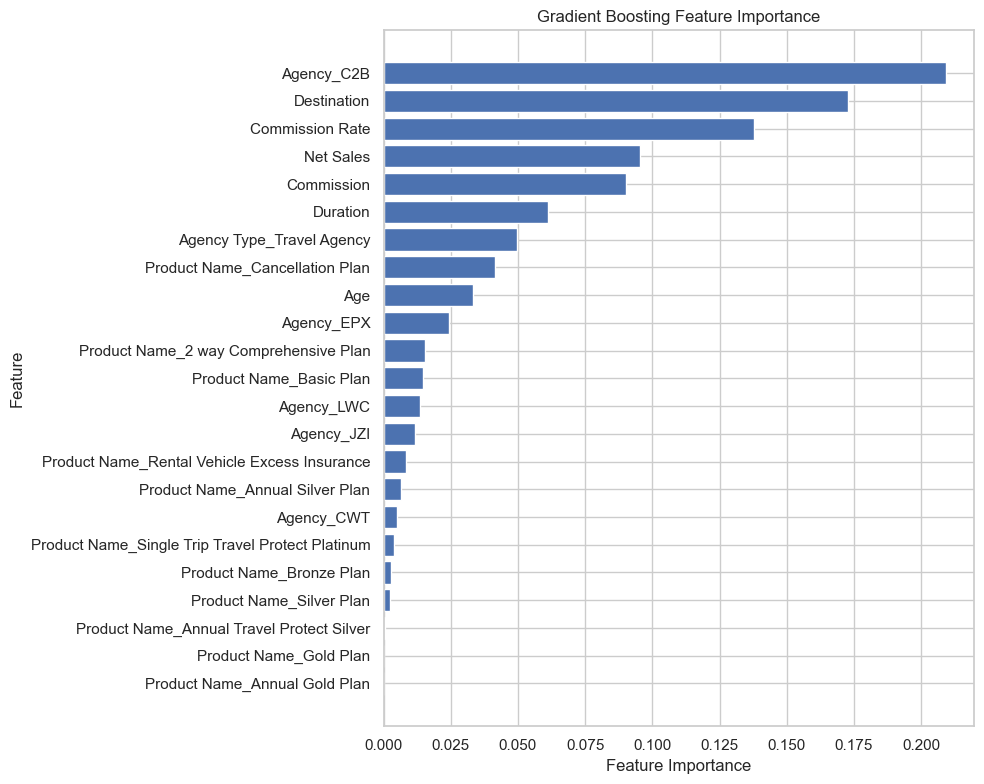

In [54]:
plt.figure(figsize=(10, 8))
plt.barh(df["Feature"], df["Importance"])

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

**6.7.2 SHAP Values (To Find Positive And Negative Impacts)**

In [55]:
x_test_transformed = tuned_pipeline[:2].transform(x_test)

model = tuned_pipeline.named_steps["classifier"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(
    x_test_transformed,
    check_additivity=False
)

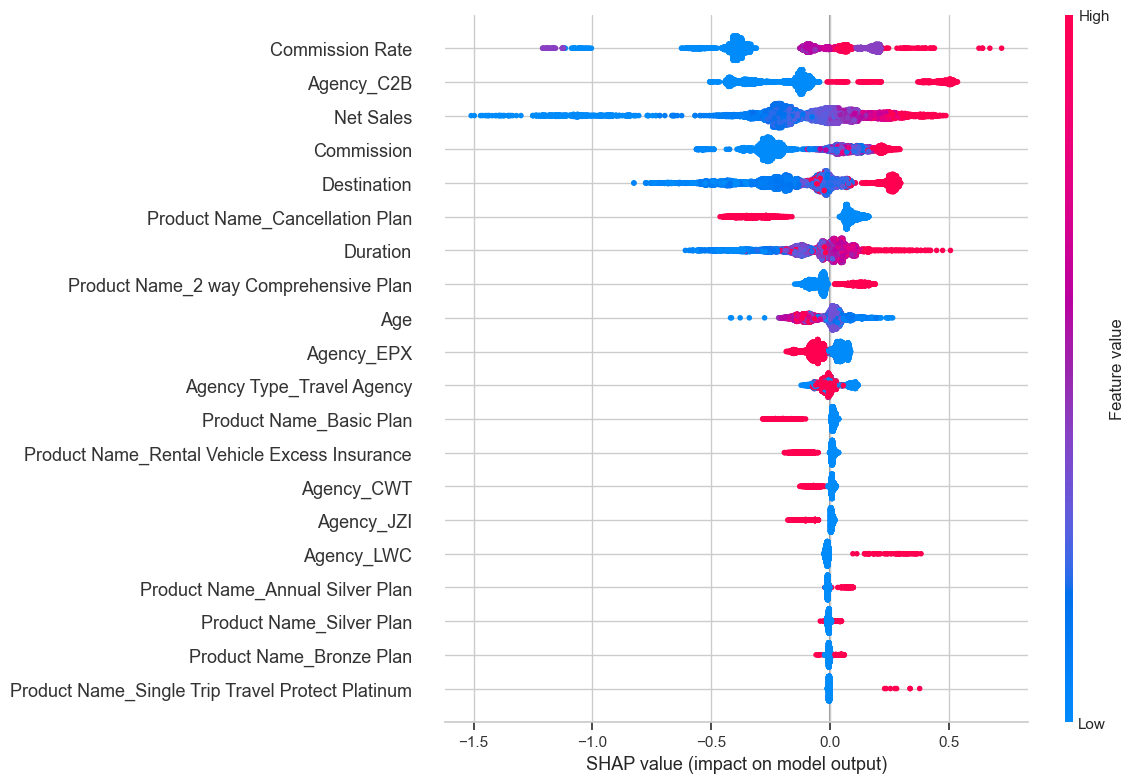

In [56]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    x_test_transformed,
    feature_names=features_names,
    show=False
)

plt.gcf().set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## **Section 7. Model Deployment**

**7.1 Export Model (joblib/pickle)**

In [58]:
tuned_pipeline.fit(x_train, y_train)

dump(tuned_pipeline, "../model/tuned_gradient_boost.joblib")

['../model/tuned_gradient_boost.joblib']

**7.2 Deployment Checklist**


**7.2.1 User Input Features**

| Feature | Type | Values / Notes |
|---|---|---|
| Agency | Categorical | C2B, EPX, JZI, CWT, LWC, ART, CSR, SSI, RAB, KML, TST, TTW, JWT, ADM, CCR, CBH |
| Agency Type | Categorical | Airlines, Travel Agency |
| Distribution Channel | Categorical | Online, Offline |
| Product Name | Categorical | 26 predefined plan types (e.g. Gold Plan, Silver Plan, Cancellation Plan) |
| Duration | Numerical | Trip length in days |
| Destination | Categorical | Must match training dataset categories |
| Net Sales | Numerical (Float) | Total sales amount |
| Age | Numerical (Integer) | Customer age |
| Commission | Numerical (Float) | Agent commission |

**7.2.2 Engineered Features (Calculated Pre-Pipeline)**

| Feature | Logic |
|---|---|
| Is Refund | "Yes" if Net Sales ≤ 0, else "No" |
| Suspected Fraud Insurance | "Yes" if Net Sales < 0 and Commission > 0, else "No" |
| Commission Rate | Commission / Net Sales if Net Sales > 0, else 0 |

**7.2.3 Prediction Flow**

1. Collect raw user input.
2. Compute engineered features (Is Refund, Suspected Fraud Insurance, Commission Rate).
3. Pass full feature set into the trained pipeline (preprocessing → encoding → transformation → prediction).

**7.2 Model Deployment Requirements**

**7.2.1 Environment**

```text
Python 3.10+
```

**7.2.2 Required Libraries**

```txt
numpy==2.2.6
pandas==2.3.3
scipy==1.15.3
scikit-learn==1.7.2
imbalanced-learn==0.14.2
xgboost==3.2.0
category-encoders==2.8.1
feature-engine==1.9.4
kneed==0.8.6
shap==0.49.1
statsmodels==0.14.6
matplotlib==3.10.9
seaborn==0.13.2
openpyxl==3.1.5
joblib==1.5.3
cloudpickle==3.1.2
tqdm==4.68.4
tabulate==0.10.0
```

**7.2.3 Installation**

```bash
python3.10 -m venv travel_env
source travel_env/bin/activate
pip install -r requirements.txt
```

**7.2.4 Model Loading**

```python
import joblib
model = joblib.load("travel_insurance_model.joblib")
```

**7.2.5 Deployment Notes**

- Use identical library versions as the training environment.
- Input features must match the training schema.
- Feature engineering logic must be identical between training and deployment.
- Ensure the model file is available before deployment.

## **Section 8. Model Implementation**

**8.1 How to Implement the Model?**

The trained model will be deployed as a **REST API**. This allows the development team to send new data to the API endpoint and receive a prediction in return, without needing direct access to the model file itself.

From this API, two implementation paths are planned:

1. **System Integration**
   The API can be integrated directly into the internal insurance system, enabling real-time or batch predictions within existing business workflows.

2. **MVP / Proof of Concept (Streamlit App)**
   For early testing, a lightweight Streamlit application will be built on top of the API. This allows relevant stakeholders to test predictions interactively and provide feedback helping the team identify which data or features may need improvement before full-scale deployment.

**8.2 What are the Limitations of the Model?**

Due to the limited size of the dataset, the model shows a slight indication of overfitting. However, the learning curve pattern is still fairly positive training error decreases and validation/test performance improves as more data is added, suggesting the model can generalize better with additional data in the future.

The main limitation lies in **true positive predictions**, since the positive class (fraud/claim cases) is a minority in the dataset, making it inherently harder for the model to detect all positive cases reliably.

To address this, the classification threshold was optimized using a cost-based approach to minimize overall business loss. The optimal threshold selected was **0.313506**, rather than the default 0.5, in order to better balance the trade-off between false positives and false negatives.

## **Section 9. Conclusion and Recommendation**

**9.1 Conclusion**

**Conclusion (Model)**
The model achieved reasonably good performance despite being trained on a limited dataset. While a slight indication of overfitting was observed, the learning curve trend remains positive, showing that model generalization is expected to improve as more data becomes available. The main weakness lies in detecting true positive cases, since the positive class (fraud/high-risk claims) is a minority in the dataset. To mitigate this, the classification threshold was optimized based on business cost rather than using the default 0.5, resulting in an optimal threshold of 0.313506 that better balances the trade-off between false positives and false negatives.

**Conclusion (Business)**
By using a cost-sensitive threshold instead of the default value, the model minimizes overall business loss reducing the risk of costly false negatives (missed fraud/claim cases, ~Rp42,000,000 each) while keeping false positive costs (manual review, ~Rp300,000 each) at a reasonable level. This directly supports the goal defined in Section 1.3, where the model is intended to help the business make more cost-efficient and data-driven decisions in identifying risky insurance transactions, while still allowing room for further improvement through additional data collection and stakeholder feedback via the MVP/POC testing phase.

**9.2 Recommendation**

**Recommendation (Model)**
- Continue collecting more data, especially for the minority (positive) class, to reduce overfitting and improve the model's ability to detect true positive cases.
- Periodically retrain and re-evaluate the model as new data becomes available to ensure performance remains stable over time.
- Explore additional features or external data sources that may help better distinguish fraudulent/high-risk transactions.
- Monitor the model's threshold periodically, as the optimal cost-based threshold may shift if business cost assumptions (FP/FN costs) change.

**Recommendation (Business)**
- Deploy the model first as an MVP/POC via the Streamlit application to gather feedback from stakeholders before full system integration.
- Use the model's predictions as a decision-support tool for the manual review/legal team, rather than fully automated decision-making, given the current limitations.
- Establish a feedback loop between business users and the data team so that misclassified cases can be reviewed and used to improve future model iterations.
- Reassess the cost matrix (FP/FN cost values) periodically to ensure the threshold remains aligned with actual business impact.